In [1]:
import pandas as pd
df = pd.read_csv("../Merge_Datasets/merged_products.csv")

## 1. Phân tích Tổng quan:

### 1.1 Thống kê số lượng bán ra thường từng danh mục con

In [2]:
qty_by_category = (
    df.groupby("sub_category")["quantity_sold"]
    .sum()
    .sort_values(ascending=False)
)
qty_by_category


sub_category
fashion_accessories    253418
women_shoes            131189
backpacks_suitcases    113250
men_bags               105548
men_shoes               95197
women_bags              40492
Name: quantity_sold, dtype: int64

In [3]:
import matplotlib.pyplot as plt

# Bảng màu cố định theo thứ tự sub_category (không đổi giữa các chart)
SUB_CATEGORIES = [
    "men_shoes",
    "women_shoes",
    "men_bags",
    "women_bags",
    "backpacks_suitcases",
    "fashion_accessories",
]
COLORS = ["#2a35d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
COLOR_MAP = dict(zip(SUB_CATEGORIES, COLORS))

INK = "#0b0b0b"
MUTED = "#898781"


def style_ax(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(MUTED)
    ax.spines["bottom"].set_color(MUTED)
    ax.grid(axis="y", alpha=0.6)
    ax.set_axisbelow(True)

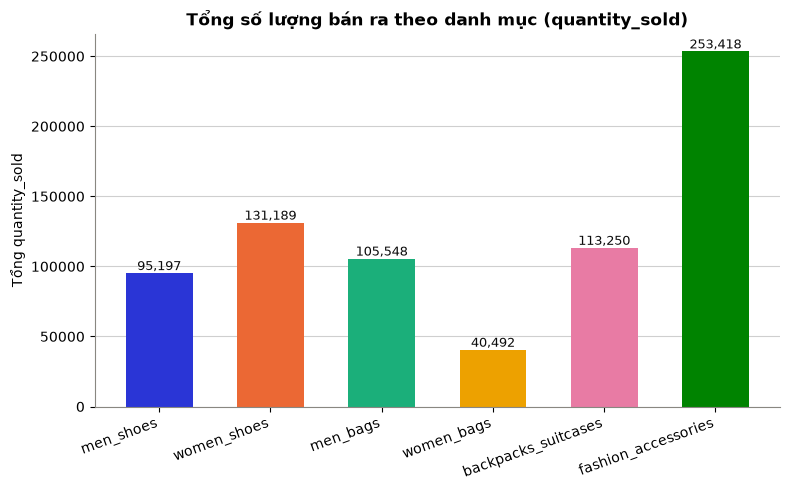

In [4]:
qty = df.groupby("sub_category")["quantity_sold"].sum().reindex(SUB_CATEGORIES)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(qty.index, qty.values, color=[COLOR_MAP[c] for c in qty.index], width=0.6)

for b, v in zip(bars, qty.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom",
             fontsize=9, color=INK)

ax.set_title("Tổng số lượng bán ra theo danh mục (quantity_sold)", fontsize=12, weight="bold")
ax.set_ylabel("Tổng quantity_sold")
ax.set_xticks(range(len(qty.index)))
ax.set_xticklabels(qty.index, rotation=20, ha="right")
style_ax(ax)
fig.tight_layout()
plt.show()

**Nhận xét:** `fashion_accessories` là "con gà đẻ trứng vàng" với 253,418 units — gấp ~1.9 lần danh mục đứng thứ 2 (`women_shoes`, 131,189) và gấp ~6.3 lần danh mục thấp nhất (`women_bags`, 40,492). Chênh lệch giữa các danh mục rất lớn, không đồng đều.


### 1.2 So sánh giá bán trung bình (price ) và tỷ lệ giảm giá trung bình (discount_rate ) trên các danh mục

In [5]:
summary = df.groupby("sub_category").agg(
    avg_price=("price", "mean"),
    avg_discount_rate=("discount_rate", "mean"),
    total_qty=("quantity_sold", "sum"),
).reindex(SUB_CATEGORIES)


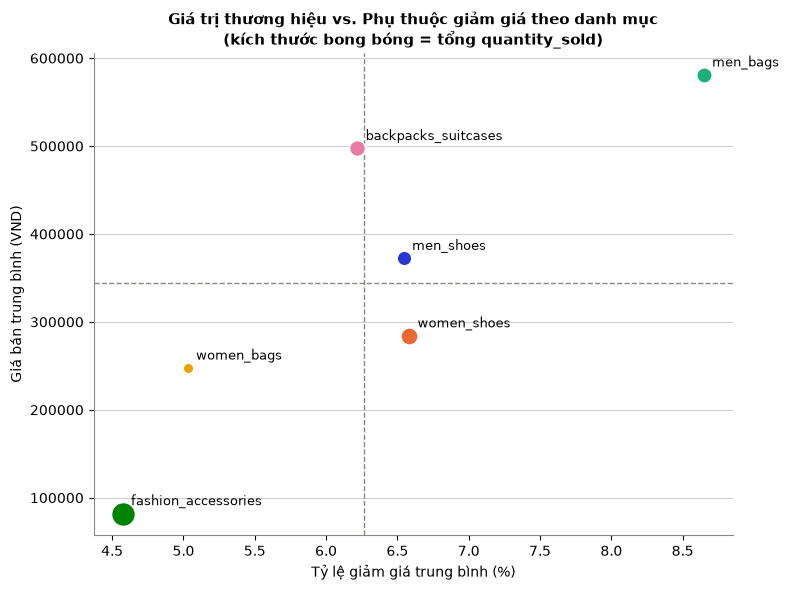

In [6]:
mean_price = summary["avg_price"].mean()
mean_disc = summary["avg_discount_rate"].mean()

fig, ax = plt.subplots(figsize=(8, 6))
sizes = 300 * (summary["total_qty"] / summary["total_qty"].max())

for cat, row in summary.iterrows():
    ax.scatter(row["avg_discount_rate"], row["avg_price"], s=max(sizes[cat], 60),
               color=COLOR_MAP[cat], edgecolor="white", linewidth=1.2, zorder=3, label=cat)
    ax.annotate(cat, (row["avg_discount_rate"], row["avg_price"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)

ax.axvline(mean_disc, color=MUTED, linestyle="--", linewidth=1)
ax.axhline(mean_price, color=MUTED, linestyle="--", linewidth=1)

ax.set_xlabel("Tỷ lệ giảm giá trung bình (%)")
ax.set_ylabel("Giá bán trung bình (VND)")
ax.set_title("Giá trị thương hiệu vs. Phụ thuộc giảm giá theo danh mục\n(kích thước bong bóng = tổng quantity_sold)",
              fontsize=11, weight="bold")
style_ax(ax)
fig.tight_layout()
plt.show()


**Nhận xét:** `men_bags` vừa có giá bán TB cao nhất (580k VND) vừa có discount TB cao nhất (8.6%) — phải giảm giá mạnh nhất để bán được hàng giá trị cao. Ngược lại, `fashion_accessories` giá thấp nhất (80k) và discount cũng thấp nhất (4.6%) — bán nhờ giá vốn rẻ chứ không phải khuyến mãi. Không danh mục nào thuộc nhóm "giá cao nhưng ít giảm giá".


## 2. Phân tích Chẩn đoán theo từng Danh mục

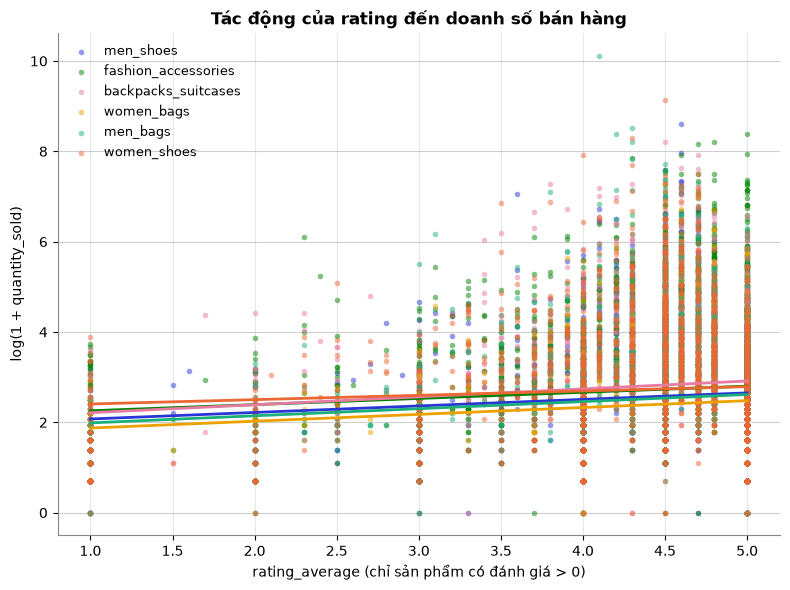

men_shoes: corr(rating_average, quantity_sold) = 0.022, slope(log qty) = 0.145
fashion_accessories: corr(rating_average, quantity_sold) = 0.056, slope(log qty) = 0.136
backpacks_suitcases: corr(rating_average, quantity_sold) = 0.036, slope(log qty) = 0.175
women_bags: corr(rating_average, quantity_sold) = 0.064, slope(log qty) = 0.152
men_bags: corr(rating_average, quantity_sold) = -0.001, slope(log qty) = 0.157
women_shoes: corr(rating_average, quantity_sold) = 0.013, slope(log qty) = 0.096


In [7]:
import numpy as np

focus_all = ["men_shoes", "fashion_accessories", "backpacks_suitcases", "women_bags", "men_bags", "women_shoes"]

fig, ax = plt.subplots(figsize=(8, 6))
corr_lines = []

for cat in focus_all:
    sub = df[df["sub_category"] == cat]
    sub = sub[sub["rating_average"] > 0]  # bỏ sản phẩm chưa có rating để không làm méo đường trend

    y = np.log1p(sub["quantity_sold"])
    ax.scatter(sub["rating_average"], y, s=16, alpha=0.5, color=COLOR_MAP[cat], label=cat, linewidths=0)

    coef = np.polyfit(sub["rating_average"], y, 1)
    xs = np.linspace(sub["rating_average"].min(), sub["rating_average"].max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color=COLOR_MAP[cat], linewidth=2)

    corr = sub["rating_average"].corr(sub["quantity_sold"])
    corr_lines.append(f"{cat}: corr(rating_average, quantity_sold) = {corr:.3f}, slope(log qty) = {coef[0]:.3f}")

ax.set_xlabel("rating_average (chỉ sản phẩm có đánh giá > 0)")
ax.set_ylabel("log(1 + quantity_sold)")
ax.set_title("Tác động của rating đến doanh số bán hàng", fontsize=12, weight="bold")
ax.legend(loc="upper left", frameon=False, fontsize=9)
style_ax(ax)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

print("\n".join(corr_lines))

### 2.1 Kiểm tra mối quan hệ giữa rating_average và quantity_sold có giống nhau ở danh mục "giày nam" và "phụ kiện thời trang" 

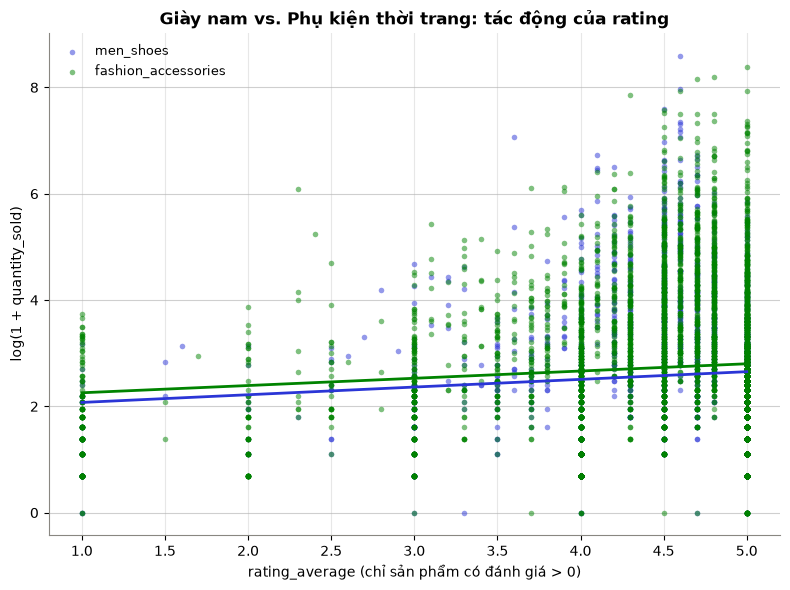

men_shoes: corr(rating_average, quantity_sold) = 0.022, slope(log qty) = 0.145
fashion_accessories: corr(rating_average, quantity_sold) = 0.056, slope(log qty) = 0.136


In [ ]:
focus = ["men_shoes", "fashion_accessories"]

fig, ax = plt.subplots(figsize=(8, 6))
corr_lines = []

for cat in focus:
    sub = df[df["sub_category"] == cat]
    sub = sub[sub["rating_average"] > 0]  # bỏ sản phẩm chưa có rating để không làm méo đường trend

    y = np.log1p(sub["quantity_sold"])
    ax.scatter(sub["rating_average"], y, s=16, alpha=0.5, color=COLOR_MAP[cat], label=cat, linewidths=0)

    coef = np.polyfit(sub["rating_average"], y, 1)
    xs = np.linspace(sub["rating_average"].min(), sub["rating_average"].max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color=COLOR_MAP[cat], linewidth=2)

    corr = sub["rating_average"].corr(sub["quantity_sold"])
    corr_lines.append(f"{cat}: corr(rating_average, quantity_sold) = {corr:.3f}, slope(log qty) = {coef[0]:.3f}")

ax.set_xlabel("rating_averagse (chỉ sản phẩm có đánh giá > 0)")
ax.set_ylabel("log(1 + quantity_sold)")
ax.set_title("Giày nam vs. Phụ kiện thời trang: tác động của rating", fontsize=12, weight="bold")
ax.legend(loc="upper left", frameon=False, fontsize=9)
style_ax(ax)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

print("\n".join(corr_lines))

**Nhận xét:** Tương quan giữa rating_average và quantity_sold rất yếu ở mọi danh mục (0.01–0.06), gồm cả men_shoes (0.022) và fashion_accessories (0.056) — gần như không có quan hệ. men_bags thậm chí gần bằng 0 (-0.001). Kết luận: rating không phải yếu tố dự đoán doanh số đáng tin cậy ở ModaVerse, mức độ yếu là tương tự nhau giữa giày nam và phụ kiện chứ không khác biệt.


### 2.2 So sánh has video or not

In [9]:
video_summary = df.groupby(["sub_category", "has_video"])["quantity_sold"].mean().unstack()
video_summary = video_summary.reindex(SUB_CATEGORIES)
video_summary.columns = ["no_video", "has_video"]
video_summary["uplift_pct"] = (
    (video_summary["has_video"] - video_summary["no_video"]) / video_summary["no_video"] * 100
).round(1)

print(video_summary)


                      no_video  has_video  uplift_pct
sub_category                                         
men_shoes            15.071688  31.884990       111.6
women_shoes          21.436670  29.038462        35.5
men_bags             25.669605  21.504225       -16.2
women_bags            7.383975  25.225000       241.6
backpacks_suitcases  17.573418  48.387722       175.3
fashion_accessories  13.476073  40.878722       203.3


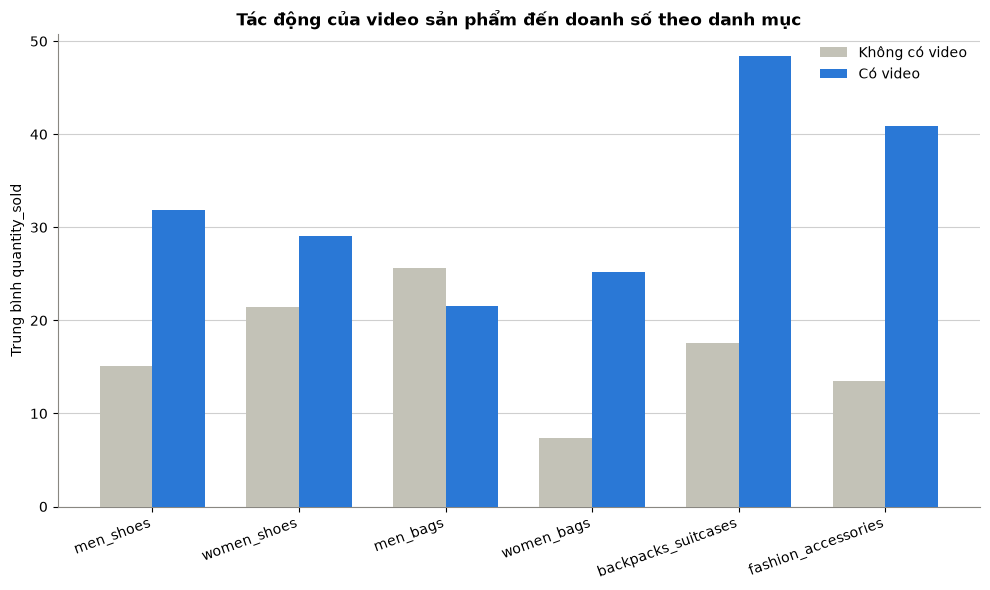

In [10]:
x = np.arange(len(SUB_CATEGORIES))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, video_summary["no_video"], width, label="Không có video", color="#c3c2b7", zorder=3)
ax.bar(x + width / 2, video_summary["has_video"], width, label="Có video", color="#2a78d6", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(SUB_CATEGORIES, rotation=20, ha="right")
ax.set_ylabel("Trung bình quantity_sold")
ax.set_title("Tác động của video sản phẩm đến doanh số theo danh mục", fontsize=12, weight="bold")
ax.legend(frameon=False)
style_ax(ax)
fig.tight_layout()
plt.show()

**Nhận xét:** Có video giúp tăng doanh số ở 5/6 danh mục, mạnh nhất ở women_bags (+241.6%) và fashion_accessories (+203.3%). Riêng men_bags là ngoại lệ duy nhất — có video lại GIẢM doanh số (-16.2%), trái ngược hoàn toàn xu hướng chung, đáng chú ý khi viết đề xuất.


### 2.3 Thương hiệu (Brand vs. OEM)

In [11]:
brand_summary = df.groupby(["sub_category", "is_branded"])["quantity_sold"].mean().unstack()
brand_summary = brand_summary.reindex(SUB_CATEGORIES)
brand_summary.columns = ["oem", "branded"]
brand_summary["uplift_pct"] = (
    (brand_summary["branded"] - brand_summary["oem"]) / brand_summary["oem"] * 100
).round(1)

print(brand_summary)


                           oem    branded  uplift_pct
sub_category                                         
men_shoes             9.330622  35.930307       285.1
women_shoes          16.744400  35.904535       114.4
men_bags              7.827174  60.108947       668.0
women_bags            4.586513  26.495228       477.7
backpacks_suitcases  11.236123  41.751438       271.6
fashion_accessories  11.553120  33.385596       189.0


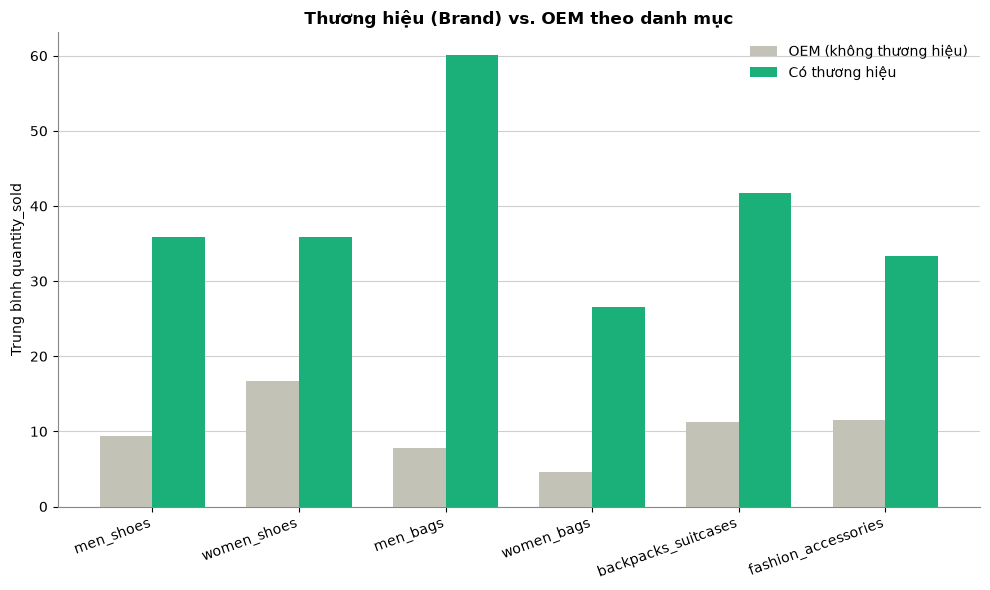

In [12]:

x = np.arange(len(SUB_CATEGORIES))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, brand_summary["oem"], width, label="OEM (không thương hiệu)", color="#c3c2b7", zorder=3)
ax.bar(x + width / 2, brand_summary["branded"], width, label="Có thương hiệu", color="#1baf7a", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(SUB_CATEGORIES, rotation=20, ha="right")
ax.set_ylabel("Trung bình quantity_sold")
ax.set_title("Thương hiệu (Brand) vs. OEM theo danh mục", fontsize=12, weight="bold")
ax.legend(frameon=False)
style_ax(ax)
fig.tight_layout()
plt.show()

**Nhận xét:** Có thương hiệu bán chạy hơn OEM ở toàn bộ 6/6 danh mục (không có ngoại lệ như video) — nhưng mức chênh lệch dao động rất lớn: từ +114.4% (women_shoes) đến +668.0% (men_bags, cao gấp gần 6 lần mức thấp nhất). Đầu tư vào brand đáng giá nhất ở men_bags/women_bags, kém hiệu quả tương đối nhất ở women_shoes.
